# Sasa & Dany · Milestone 1 · Pre-cleaning profile

**What this notebook is:** the exploratory data analysis (EDA) we do *before* any cleaning, for 11 of the 14 tables:
`seasons`, `circuits`, `drivers`, `constructors`, `status`, `sprint_results`, `driver_standings`,
`lap_times`, `pit_stops`, `constructor_standings`, `constructor_results`.

**Why:** the brief asks for EDA before cleaning, backed by code and plots instead of looking at rows by eye.
What we find here decides how each table is cleaned later, and feeds the data-engineering questions,
the features and the report.

**One rule for the whole notebook:** the raw files are never changed. Every step works on copies.

## P0 · Setup: load untouched, fingerprint, build helpers

- **What:** load our 11 CSV files exactly as delivered (every column as text), save a fingerprint of each one, and define four helper functions.
- **Why:**
  - Reading everything as text keeps the `\N` placeholders visible, so we can count them instead of letting pandas hide them.
  - The fingerprint lets us prove at the end (step D3) that the raw data was never modified, as the brief requires.
  - The helpers (`as_num`, `year_of`, `profile`, `pk_check`) make every later step use the same checks, so our EDA is code, not manual inspection.

In [1]:
# ==========================================================================================
# P0 · SETUP: load our 11 tables exactly as they are, and build the helpers every step uses
# ==========================================================================================

# ---------- 1. Libraries ----------
import os                          # to find the folder where Kaggle put the dataset
import numpy as np                 # gives us NaN, the real "missing value" marker
import pandas as pd                # tables (DataFrames): reading, counting, grouping
import matplotlib.pyplot as plt    # basic plots
import seaborn as sns              # nicer statistical plots (heatmaps, etc.)

pd.set_option("display.max_columns", 50)   # show every column when we display a table

# Library versions: Kaggle's versions can differ from our laptops, so we print them for reproducibility
print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)


# ---------- 2. Where is the data? ----------
# Kaggle puts attached datasets somewhere under /kaggle/input. Instead of guessing the exact
# folder name, we search for the folder that contains races.csv. On a laptop we fall back to ./data
def find_data_dir():
    for folder, _, files in os.walk("/kaggle/input"):
        if "races.csv" in files:
            return folder
    return "data"

DATA_DIR = find_data_dir()
csv_files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith(".csv"))
print("Data folder:", DATA_DIR)
print("CSV files found:", len(csv_files))          # we expect 14


# ---------- 3. The 11 tables we (Sasa & Dany) profile ----------
# races, results and qualifying are profiled by our teammates; we only read them for lookups.
MINE = ["seasons", "circuits", "drivers", "constructors", "status", "sprint_results",
        "driver_standings", "lap_times", "pit_stops", "constructor_standings", "constructor_results"]

# The dataset does not leave missing cells empty: it writes the text \N instead.
# A value that "stands in" for missing like this is called a sentinel.
SENT = r"\N"


# ---------- 4. Load every file exactly as it is (the "bronze" layer) ----------
# dtype=str              -> read every column as text, so pandas does not guess the types for us
# keep_default_na=False  -> pandas must not turn anything into NaN by itself, so \N stays visible
raw = {t: pd.read_csv(f"{DATA_DIR}/{t}.csv", dtype=str, keep_default_na=False)
       for t in MINE + ["races", "results"]}

# A fingerprint (hash) of every raw table. In step D3 we compute it again and compare,
# to PROVE we never changed the raw data (the brief: "Raw CSV files remain immutable").
RAW_HASH = {t: pd.util.hash_pandas_object(df).sum() for t, df in raw.items()}


# ---------- 5. Two lookups we need in many steps ----------
# races: turn \N into NaN and make ids and year numeric, so we can find the season of any raceId
races = raw["races"].replace(SENT, np.nan).astype({"raceId": int, "year": int, "round": int, "circuitId": int})
races["date"] = pd.to_datetime(races["date"])      # race date as a real date, not text
YEAR = races.set_index("raceId")["year"]           # quick lookup: raceId -> season year
results = raw["results"].replace(SENT, np.nan)     # results with \N as NaN, used only for cross-checks


# ---------- 6. Helper functions (the same checks for every table) ----------
def as_num(df):
    # Returns a COPY for exploring: \N becomes NaN, and every column made only of numbers becomes numeric.
    # Columns that contain any text (e.g. lap times like "1:26.572") stay text, so we can still see their format.
    out = df.replace(SENT, np.nan)
    for c in out.columns:
        conv = pd.to_numeric(out[c], errors="coerce")     # try to read the column as numbers
        if conv.notna().sum() == out[c].notna().sum():    # did EVERY non-missing value convert?
            out[c] = conv                                 # yes -> keep the numeric version
    return out


def year_of(df):
    # The season year of every row, for any table that has a raceId column
    return pd.to_numeric(df["raceId"]).map(YEAR)


def profile(t):
    # A "profile card" for table t: one row per column, with the checks we care about
    df = raw[t]
    return pd.DataFrame({
        "sentinel_N": df.eq(SENT).sum(),                     # how many \N in the column
        "sentinel_%": (df.eq(SENT).mean() * 100).round(2),   # the same, as a % of the rows
        "empty_str": df.eq("").sum(),                        # truly empty cells (we expect 0)
        "unique": df.nunique(),                              # how many different values
        "numeric_%": df.apply(lambda s: pd.to_numeric(s, errors="coerce").notna().mean() * 100).round(1),  # % that read as numbers
        "example": df.iloc[0]})                              # the first value, to see the format


def pk_check(t, cols):
    # Checks a primary key: the column(s) that should identify each row of table t
    df = raw[t]
    return {"table": t, "key": "+".join(cols), "rows": len(df),
            "duplicates": int(df.duplicated(cols).sum()),                          # rows whose key appears again
            "null_or_sentinel": int(df[cols].isin(["", SENT]).any(axis=1).sum())}  # rows with a missing key


# ---------- 7. First output: how big is each of our 11 tables? ----------
sizes = pd.DataFrame({t: raw[t].shape for t in MINE}, index=["rows", "columns"]).T
sizes

pandas 2.3.3 | numpy 2.1.3 | seaborn 0.13.2
Data folder: /kaggle/input/datasets/rohanrao/formula-1-world-championship-1950-2020
CSV files found: 14


,rows,columns
seasons,75,2
circuits,77,9
drivers,861,9
constructors,212,5
status,139,2
sprint_results,360,16
driver_standings,34863,7
lap_times,589081,6
pit_stops,11371,7
constructor_standings,13391,7


**P0 result:** the dataset folder holds all 14 CSV files, and our 11 tables loaded with the sizes above.
`lap_times` is by far the biggest (589,081 rows); `seasons` and `status` are tiny lookup lists.
Nothing has been cleaned or changed; this is the starting point every later step builds on.

## A1 · seasons: complete list of years, and how season length changed

- **What:** profile the `seasons` table, check that its key (`year`) is unique and complete from 1950 to 2024, compare it with `races`, and plot how many races each season had.
- **Why:**
  - `seasons` is the list of years every other table relies on. A missing or repeated year would break joins and per-season counts.
  - Season length matters later: 5 wins in a 7-race season is not the same as 5 wins in a 24-race season, so we need to know how much it changed.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
year,0,0.0,0,75,100.0,2009
url,0,0.0,0,75,0.0,http://en.wikipedia.org/wiki/2009_Formula_One_...


{'table': 'seasons', 'key': 'year', 'rows': 75, 'duplicates': 0, 'null_or_sentinel': 0}
Every year 1950-2024 present: True
File order starts with: [2009, 2008, 2007] | sorted by year: False
Seasons with no races: set() | Race years missing from seasons: set()
url unique per season: True | every url contains its own year: True | example: http://en.wikipedia.org/wiki/2009_Formula_One_season
Fewest races in a season: 7 | most: 24
Seasons with the fewest races: [1950, 1955]
Seasons with the most races: [2024]


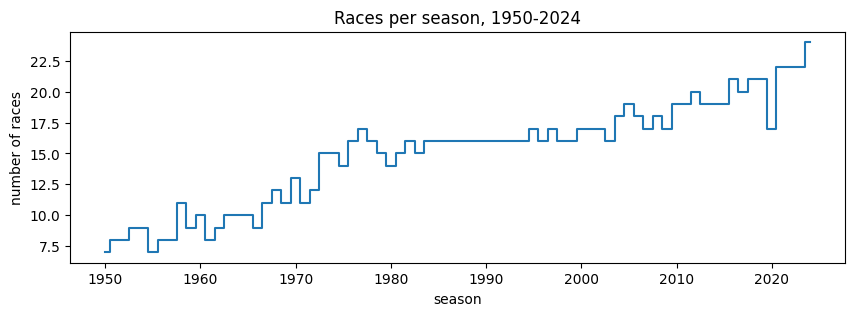

In [2]:
# ==========================================================================================
# A1 · seasons: is the list of years complete, and how did the length of a season change?
# ==========================================================================================

# An exploring copy of seasons: \N -> NaN and number columns -> numbers (raw stays untouched)
se = as_num(raw["seasons"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("seasons"))

# ---------- 2. Primary key: does "year" identify every row? ----------
# A good key has no repeated values and no missing values
print(pk_check("seasons", ["year"]))

# ---------- 3. Is every season from 1950 to 2024 there, with no gaps? ----------
print("Every year 1950-2024 present:", sorted(se.year) == list(range(1950, 2025)))

# ---------- 4. Is the file sorted by year? ----------
# We print the first 3 years in the order they appear in the file
print("File order starts with:", se.year.head(3).tolist(),
      "| sorted by year:", se.year.is_monotonic_increasing)

# ---------- 5. Do seasons and races agree with each other? ----------
# Every season should have races, and every year that has races should be in seasons
print("Seasons with no races:", set(se.year) - set(races.year),
      "| Race years missing from seasons:", set(races.year) - set(se.year))

# ---------- 6. What is the url column? ----------
# If every url is different and simply contains its own year, it is only a Wikipedia link, not data
print("url unique per season:", se.url.is_unique,
      "| every url contains its own year:", all(str(y) in u for y, u in zip(se.year, se.url)),
      "| example:", se.url.iloc[0])

# ---------- 7. How long was each season? ----------
races_per_season = races.groupby("year").size()          # number of races in each season
print("Fewest races in a season:", races_per_season.min(), "| most:", races_per_season.max())
print("Seasons with the fewest races:", list(races_per_season[races_per_season == races_per_season.min()].index))
print("Seasons with the most races:", list(races_per_season[races_per_season == races_per_season.max()].index))

# ---------- 8. Plot: races per season (saved for the report) ----------
ax = races_per_season.plot(drawstyle="steps-mid", figsize=(10, 3), title="Races per season, 1950-2024")
ax.set_xlabel("season")
ax.set_ylabel("number of races")
os.makedirs("figures", exist_ok=True)                                     # folder for all report figures
plt.savefig("figures/A1_races_per_season.png", dpi=120, bbox_inches="tight")
plt.show()

**A1 result:**
- 75 rows, one per season from 1950 to 2024: no gaps, no repeats, no `\N`, nothing empty. `year` is a valid primary key.
- The file is **not sorted**: it starts 2009, 2008, 2007.
- `seasons` and `races` agree perfectly: every season has races, and every race year is listed.
- `url` is only a Wikipedia link (different for every season and always containing its own year). It carries no information for the model.
- Season length grew from **7 races** (1950 and 1955) to **24 races** (2024).

**Decisions for cleaning:** sort by `year`; drop or ignore `url`; whenever we count something per season (wins, podiums, points), turn it into a rate or share, because seasons range from 7 to 24 races.

## A2 · circuits: profile, keys and types

- **What:** profile the `circuits` table, check its key and the other identifier columns, confirm each column's type, check that the coordinates are physically possible, and look for text problems (extra spaces, odd names, broken accents).
- **Why:** `circuits` is a lookup table: every race points to one circuit, question 1 ranks circuits, and question 2 uses their country. A broken key or a wrongly typed column here would silently break those joins later.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
circuitId,0,0.0,0,77,100.0,1
circuitRef,0,0.0,0,77,0.0,albert_park
name,0,0.0,0,77,0.0,Albert Park Grand Prix Circuit
location,0,0.0,0,75,0.0,Melbourne
country,0,0.0,0,35,0.0,Australia
lat,0,0.0,0,77,100.0,-37.8497
lng,0,0.0,0,77,100.0,144.968
alt,0,0.0,0,66,100.0,10
url,0,0.0,0,77,0.0,http://en.wikipedia.org/wiki/Melbourne_Grand_P...


{'table': 'circuits', 'key': 'circuitId', 'rows': 77, 'duplicates': 0, 'null_or_sentinel': 0}
circuitRef unique: True | name unique: True | url unique: True
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
alt             int64
url            object
dtype: object


,lat,lng,alt
count,77.00,77.00,77.00
mean,33.44,1.08,247.01
std,22.81,65.52,362.74
min,-37.85,-118.19,-7.00
25%,32.78,-9.39,18.00
50%,40.95,3.93,129.00
75%,46.96,19.25,332.00
max,57.27,144.97,2227.00


lat within [-90, 90]: True | lng within [-180, 180]: True
lat: min -37.8497 (Albert Park Grand Prix Circuit, Australia) | max 57.2653 (Scandinavian Raceway, Sweden)
lng: min -118.189 (Long Beach, USA) | max 144.968 (Albert Park Grand Prix Circuit, Australia)
alt: min -7 (Baku City Circuit, Azerbaijan) | max 2227 (Autódromo Hermanos Rodríguez, Mexico)
values with leading/trailing spaces: {'circuitRef': 0, 'name': 0, 'location': 0, 'country': 0, 'url': 0}
circuitRef values breaking the usual pattern: ['ain-diab']
names with accented letters (they must display correctly): ['Autódromo José Carlos Pace', 'Nürburgring', 'Autódromo Juan y Oscar Gálvez', 'Autódromo do Estoril']
url starting with https: 1 | with http: 76


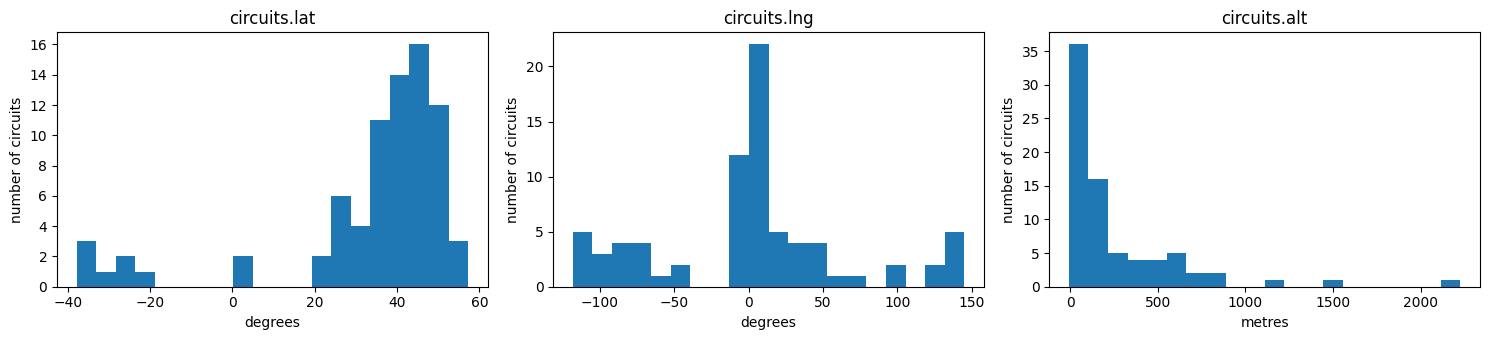

In [3]:
# ==========================================================================================
# A2 · circuits: profile, keys, types and basic sanity of every column
# ==========================================================================================

# An exploring copy of circuits: \N -> NaN and number columns -> numbers (raw stays untouched)
ci = as_num(raw["circuits"])

# ---------- 1. Profile card: one row per column ----------
# Shows, for each column, how many \N there are, how many different values, and an example value
display(profile("circuits"))

# ---------- 2. Keys: does circuitId identify every row? Are the other identifiers unique too? ----------
print(pk_check("circuits", ["circuitId"]))
print("circuitRef unique:", ci.circuitRef.is_unique, "| name unique:", ci.name.is_unique, "| url unique:", ci.url.is_unique)

# ---------- 3. Types: which columns became numbers, which stayed text? ----------
print(ci.dtypes)

# ---------- 4. Do the coordinates make sense? ----------
# Latitude must be between -90 and 90 and longitude between -180 and 180; altitude is in metres above sea level
display(ci[["lat", "lng", "alt"]].describe().round(2))
print("lat within [-90, 90]:", ci.lat.between(-90, 90).all(), "| lng within [-180, 180]:", ci.lng.between(-180, 180).all())
for col in ["lat", "lng", "alt"]:                                  # which circuit sits at each extreme?
    lo, hi = ci.loc[ci[col].idxmin()], ci.loc[ci[col].idxmax()]
    print(f"{col}: min {lo[col]} ({lo['name']}, {lo['country']}) | max {hi[col]} ({hi['name']}, {hi['country']})")

# ---------- 5. Text hygiene: stray spaces, naming pattern, accented letters, link format ----------
text_cols = ["circuitRef", "name", "location", "country", "url"]
print("values with leading/trailing spaces:", {c: int((ci[c] != ci[c].str.strip()).sum()) for c in text_cols})
bad_ref = ci.circuitRef[~ci.circuitRef.str.match(r"^[a-z0-9_]+$")]    # refs are normally lower_case_with_underscores
print("circuitRef values breaking the usual pattern:", bad_ref.tolist())
has_accent = ci.name.map(lambda s: not s.isascii())                    # True when a name has a non-English letter (é, ü, ...)
print("names with accented letters (they must display correctly):", ci.name[has_accent].tolist()[:4])
print("url starting with https:", ci.url.str.startswith("https").sum(), "| with http:", ci.url.str.startswith("http:").sum())

# ---------- 6. Plot: how latitude, longitude and altitude are spread (saved for the report) ----------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
for a, col, unit in zip(ax, ["lat", "lng", "alt"], ["degrees", "degrees", "metres"]):
    ci[col].plot.hist(bins=20, ax=a, title=f"circuits.{col}")
    a.set_xlabel(unit)
    a.set_ylabel("number of circuits")
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/A2_circuit_coordinates.png", dpi=120, bbox_inches="tight")
plt.show()

**A2 result:**
- 77 circuits, 9 columns, with **no `\N` and no empty cells at all**: nothing to fill in.
- `circuitId` is a valid primary key, and `circuitRef`, `name` and `url` are unique too.
- Types are right: `circuitId`, `lat`, `lng` and `alt` are numbers; everything else is text.
- Every coordinate is physically possible: latitude runs from −37.85 (Albert Park, Australia) to 57.27 (Scandinavian Raceway, Sweden), and altitude from −7 m (Baku, below sea level) to 2,227 m (Mexico City).
- Text is clean: no stray spaces, and accented names (Autódromo, Nürburgring) are read correctly. Two cosmetic quirks: the `circuitRef` "ain-diab" uses a hyphen instead of an underscore, and 1 of the 77 links uses https while the rest use http.

**Decisions for cleaning:** nothing needs fixing here; keep `circuitId` as the only join key (never join on name or ref); `url` is not needed; altitude gets a closer look in A3.

## A3 · circuits: how often each was used, and where

- **What:** join `circuits` to `races` to count how many Grands Prix each circuit hosted and in which seasons, split the count into the eras "up to 2013" and "from 2014", check whether a circuit ever hosts two races in one season, and plot where the circuits are.
- **Why:** question 1 ranks circuits by how often a front-row start becomes a podium, before and after 2014. A circuit with 3 races cannot be ranked fairly against one with 70, so we must know how many races each circuit has, and how many circuits exist in *both* eras, before we choose a minimum-sample rule.

Circuits that never hosted a race: 0 | hosted exactly one race: 11


,name,races,first,last
13,Autodromo Nazionale di Monza,74,1950,2024
5,Circuit de Monaco,70,1950,2024
8,Silverstone Circuit,59,1950,2024
12,Circuit de Spa-Francorchamps,57,1950,2024
6,Circuit Gilles Villeneuve,43,1978,2024


,name,country,first
30,Donington Park,UK,1993
41,Fair Park,USA,1984
53,Le Mans,France,1967
56,Zeltweg,Austria,1964
59,Riverside International Raceway,USA,1960
60,AVUS,Germany,1959
61,Monsanto Park Circuit,Portugal,1959
62,Sebring International Raceway,USA,1959
63,Ain Diab,Morocco,1958
64,Pescara Circuit,Italy,1957


Circuits used up to 2013: 69 | from 2014: 32
Used in both eras: 24 | only up to 2013: 45 | only from 2014: 8
Circuits that first appear from 2014: ['Sochi Autodrom', 'Baku City Circuit', 'Autódromo Internacional do Algarve', 'Autodromo Internazionale del Mugello', 'Jeddah Corniche Circuit', 'Losail International Circuit', 'Miami International Autodrome', 'Las Vegas Strip Street Circuit']


,at least 1 races,at least 5 races,at least 10 races
up to 2013,69,45,30
from 2014,32,19,11
in BOTH eras,24,16,8


Seasons where one circuit hosted 2 or more races: [2020, 2021]
Circuits that hosted more than one differently named Grand Prix: 12 | most names at one circuit: 4 -> Nürburgring
Circuits with altitude exactly 0 m: [['yeongam', 'Yeongam County'], ['miami', 'Miami']]
Lowest 4 altitudes: [['baku', -7], ['yeongam', 0], ['miami', 0], ['sochi', 2]]


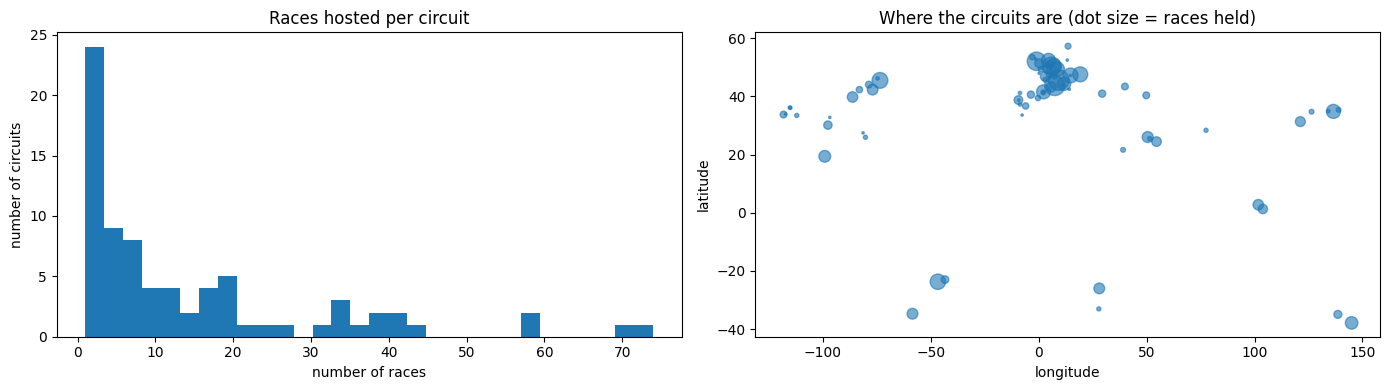

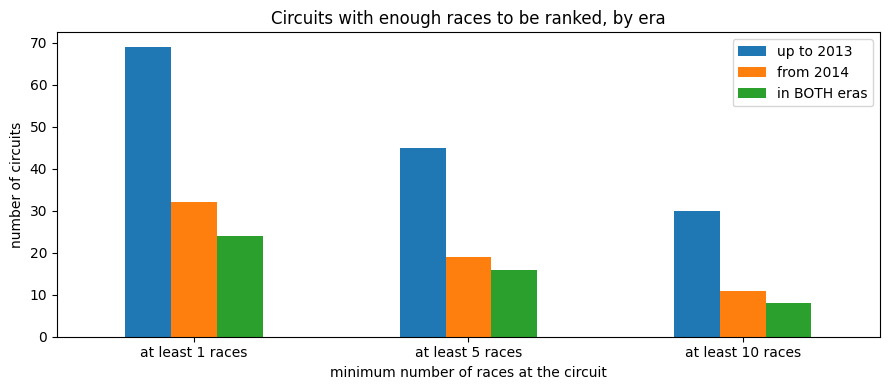

In [4]:
# ==========================================================================================
# A3 · circuits + races: how often was each circuit used, when, and where?
# ==========================================================================================

# Why: question 1 ranks circuits, so we need to know how many races each circuit hosted.
# A circuit with only 3 races cannot be ranked fairly against one with 70.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)

# ---------- 1. For every circuit: how many races, first season, last season ----------
rc = races.groupby("circuitId").agg(races=("raceId", "size"),      # number of Grands Prix held there
                                    first=("year", "min"),         # first season at this circuit
                                    last=("year", "max"))          # last season at this circuit
ci2 = ci.merge(rc, left_on="circuitId", right_index=True, how="left")   # attach the counts to the circuits table (a copy)

print("Circuits that never hosted a race:", ci2.races.isna().sum(),
      "| hosted exactly one race:", (ci2.races == 1).sum())
display(ci2.nlargest(5, "races")[["name", "races", "first", "last"]])      # the 5 most used circuits
display(ci2[ci2.races == 1][["name", "country", "first"]])                 # the one-off circuits

# ---------- 2. Before and after 2014: which circuits were used? ----------
# Question 1 compares the era up to 2013 with the era from 2014 on, so we count races per circuit in each era
n_early = races[races.year <= 2013].groupby("circuitId").size()    # races per circuit, seasons up to 2013
n_modern = races[races.year >= 2014].groupby("circuitId").size()   # races per circuit, seasons from 2014
both = sorted(set(n_early.index) & set(n_modern.index))            # circuits used in BOTH eras
print("Circuits used up to 2013:", len(n_early), "| from 2014:", len(n_modern))
print("Used in both eras:", len(both),
      "| only up to 2013:", len(n_early) - len(both), "| only from 2014:", len(n_modern) - len(both))
new_circuits = sorted(set(n_modern.index) - set(n_early.index))     # circuits that appear for the first time after 2013
print("Circuits that first appear from 2014:", ci.set_index("circuitId").name.reindex(new_circuits).tolist())

# How many circuits have enough races to be ranked? (at least 1, 5 or 10 races)
enough = pd.DataFrame(
    {f"at least {k} races": [int((n_early >= k).sum()), int((n_modern >= k).sum()),
                             int(((n_early.reindex(both) >= k) & (n_modern.reindex(both) >= k)).sum())]
     for k in [1, 5, 10]},
    index=["up to 2013", "from 2014", "in BOTH eras"])
display(enough)

# ---------- 3. Does a circuit ever host two races in the same season? ----------
per_season = races.groupby("year").agg(races=("raceId", "size"), circuits=("circuitId", "nunique"))
repeat = per_season[per_season.races > per_season.circuits]        # seasons with fewer circuits than races
print("Seasons where one circuit hosted 2 or more races:", repeat.index.tolist())

# ---------- 4. Does one circuit host Grands Prix with different names? ----------
names_per_circuit = races.groupby("circuitId").name.nunique()      # how many different race names per circuit
print("Circuits that hosted more than one differently named Grand Prix:", int((names_per_circuit > 1).sum()),
      "| most names at one circuit:", int(names_per_circuit.max()),
      "->", ci.set_index("circuitId").name[names_per_circuit.idxmax()])

# ---------- 5. Altitude: how many circuits sit at or near sea level? ----------
print("Circuits with altitude exactly 0 m:", ci[ci.alt == 0][["circuitRef", "location"]].values.tolist())
print("Lowest 4 altitudes:", ci.sort_values("alt")[["circuitRef", "alt"]].head(4).values.tolist())

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ci2.races.plot.hist(bins=30, ax=ax[0], title="Races hosted per circuit")
ax[0].set_xlabel("number of races")
ax[0].set_ylabel("number of circuits")
ax[1].scatter(ci2.lng, ci2.lat, s=ci2.races * 3, alpha=.6)        # each circuit is a dot; a bigger dot = more races
ax[1].set_title("Where the circuits are (dot size = races held)")
ax[1].set_xlabel("longitude")
ax[1].set_ylabel("latitude")
plt.tight_layout()
plt.savefig("figures/A3_circuit_usage.png", dpi=120, bbox_inches="tight")
plt.show()

enough.T.plot.bar(figsize=(9, 4), rot=0, title="Circuits with enough races to be ranked, by era")
plt.xlabel("minimum number of races at the circuit")
plt.ylabel("number of circuits")
plt.tight_layout()
plt.savefig("figures/A3_circuits_by_era.png", dpi=120, bbox_inches="tight")
plt.show()

**A3 result:**
- Every one of the 77 circuits hosted at least one race. **11 hosted exactly one** (for example Donington Park and Pescara). The most used are Monza (74 races), Monaco (70), Silverstone (59), Spa (57) and Circuit Gilles Villeneuve (43).
- **The ranking pool shrinks after 2013:** 69 circuits were used up to 2013 but only 32 from 2014. Just **24 circuits appear in both eras**; 45 disappeared and 8 are new (Sochi, Baku, Algarve, Mugello, Jeddah, Losail, Miami, Las Vegas).
- Requiring at least 5 races in each era leaves only **16 circuits** for the before/after comparison, and at least 10 races leaves only **8**.
- **One circuit can host two races in a season:** this happened in 2020 (Red Bull Ring, Silverstone, Bahrain) and 2021, so `(year, circuitId)` does **not** identify a single race.
- 12 circuits hosted Grands Prix under different names (the Nürburgring under 4), so Q1 must group by `circuitId`, not by race name.
- Altitude: Baku is below sea level (−7 m); Yeongam and Miami are exactly 0 m, which may be a real near-sea-level value or a default.

**Decisions for cleaning and Q1:** group circuits by `circuitId` only; set a minimum number of races before a circuit is ranked and say which (5 per era keeps 16 circuits for the comparison); never assume one race per circuit per season; if altitude is ever used, flag `alt = 0` as possibly unknown.

## A4 · circuits: country names, for question 2

- **What:** list every country spelling in `circuits` with its number of circuits and races, look for abbreviations and for two spellings of the same country, and test whether circuit countries can be matched directly to driver nationalities.
- **Why:** question 2 asks whether drivers podium more often at **home**. A home race is one where the driver's nationality matches the circuit's country, so before we can build that match we must know exactly how both sides are written. If the spellings are inconsistent, some home races would be silently missed.

Different country spellings: 35


,circuits,races
country,,
Italy,4,107
Germany,3,79
UK,4,79
USA,11,77
Monaco,1,70
Belgium,3,69
France,7,63
Spain,6,61
Canada,3,53


Abbreviated country names: ['UK', 'USA', 'UAE']
Both 'USA' and 'United States' present: True


,circuitRef,location,country
18,indianapolis,Indianapolis,USA
32,phoenix,Phoenix,USA
36,detroit,Detroit,USA
41,dallas,Dallas,USA
42,long_beach,California,USA
43,las_vegas,Nevada,USA
45,watkins_glen,New York State,USA
59,riverside,California,USA
62,sebring,Florida,USA
68,americas,Austin,USA


Countries before merging: 35 | after merging 'United States' into 'USA': 34
Circuits in the USA after merging: 12
Circuit countries spelled exactly like a driver nationality: [] (0 of 35)
Examples of the mismatch: circuits say ['UK', 'Germany', 'Monaco'] | drivers say ['British', 'German', 'Monegasque']


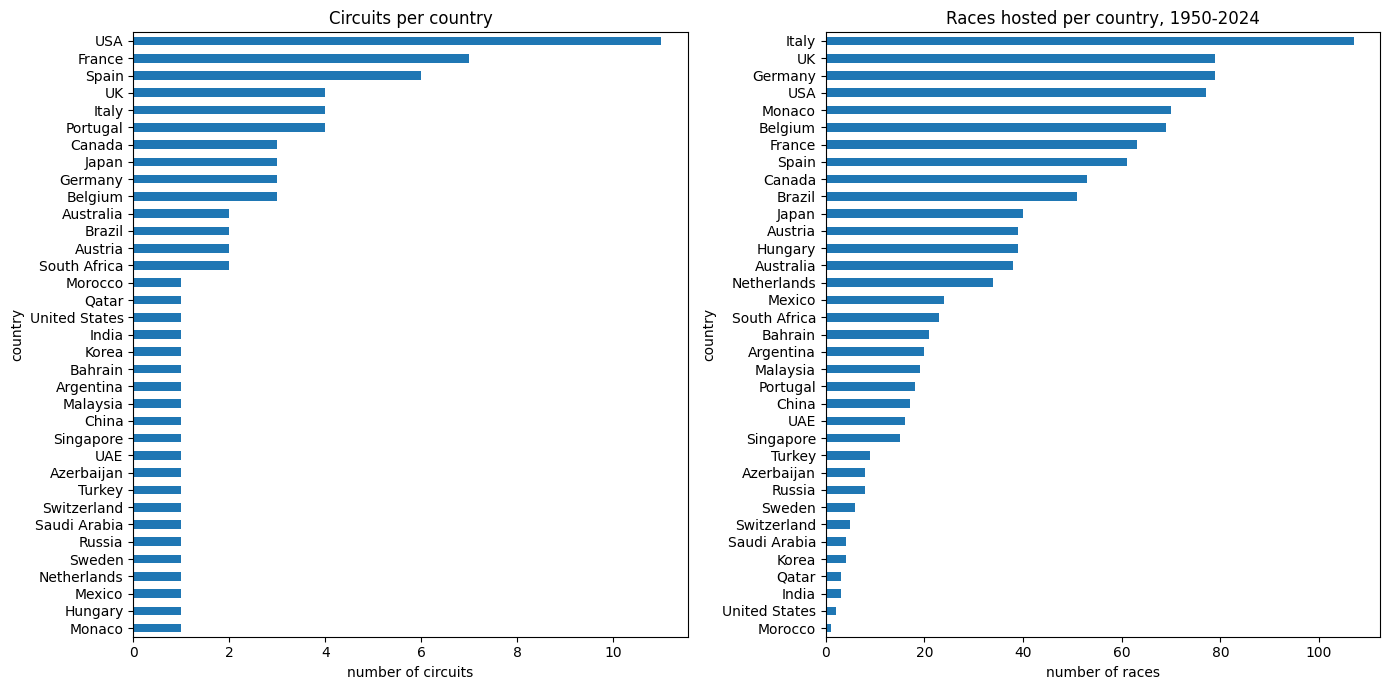

In [5]:
# ==========================================================================================
# A4 · circuits + drivers: how are countries spelled, and can they be matched to driver nationalities?
# ==========================================================================================

# Why: question 2 asks "do drivers podium more at HOME?". A home race is one where the driver's nationality
# matches the circuit's country, so before we can build that match we must know how both sides are written.
ci = as_num(raw["circuits"])          # exploring copy of circuits (raw stays untouched)
dr = as_num(raw["drivers"])           # exploring copy of drivers, only to compare the two vocabularies

# ---------- 1. Every country spelling, with how many circuits and races it has ----------
races_per_country = (races.merge(ci[["circuitId", "country"]], on="circuitId")   # give every race its circuit's country
                          .groupby("country").size().rename("races"))
country_table = (ci.groupby("country").size().rename("circuits").to_frame()       # circuits per country
                   .join(races_per_country)                                       # add races per country
                   .sort_values("races", ascending=False))
print("Different country spellings:", len(country_table))
display(country_table)

# ---------- 2. Which spellings are abbreviations, or two spellings of the same country? ----------
abbreviations = [c for c in country_table.index if c.isupper() and len(c) <= 3]   # UK, UAE, USA ...
print("Abbreviated country names:", abbreviations)
print("Both 'USA' and 'United States' present:", {"USA", "United States"} <= set(country_table.index))
display(ci[ci.country.isin(["USA", "United States"])][["circuitRef", "location", "country"]].sort_values("country"))

# ---------- 3. What happens if we merge those two spellings? ----------
usa_fixed = ci.country.replace({"United States": "USA"})          # a copy; the raw table is untouched
print("Countries before merging:", ci.country.nunique(), "| after merging 'United States' into 'USA':", usa_fixed.nunique())
print("Circuits in the USA after merging:", int((usa_fixed == "USA").sum()))

# ---------- 4. Can we simply join circuit countries to driver nationalities? ----------
# A home race needs "British driver" <-> "UK circuit". We test whether the words are ever identical.
same_words = sorted(set(ci.country) & set(dr.nationality))
print("Circuit countries spelled exactly like a driver nationality:", same_words, f"({len(same_words)} of {ci.country.nunique()})")
print("Examples of the mismatch: circuits say", ["UK", "Germany", "Monaco"], "| drivers say", ["British", "German", "Monegasque"])

# ---------- 5. Plot: where F1 circuits are, and where the races were (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
country_table.circuits.sort_values().plot.barh(ax=ax[0], title="Circuits per country")
ax[0].set_xlabel("number of circuits")
country_table.races.sort_values().plot.barh(ax=ax[1], title="Races hosted per country, 1950-2024")
ax[1].set_xlabel("number of races")
plt.tight_layout()
plt.savefig("figures/A4_circuits_per_country.png", dpi=120, bbox_inches="tight")
plt.show()

**A4 result:**
- The table has **35 country spellings**. Italy hosted the most races (107), then the UK and Germany (79 each); Monaco hosted 70 from a single circuit.
- Three names are **abbreviations** (`UK`, `USA`, `UAE`), and `Korea` is a short form.
- **The USA is spelled two ways.** Eleven circuits say `USA`, but the newer Las Vegas Strip circuit says `United States` (only 2 races). Merging them gives **34 countries**, **12 US circuits** and 79 US races, the same as the UK and Germany.
- **The two sides never match as written:** 0 of the 35 circuit countries are spelled like a driver nationality (circuits say "UK", "Germany", "Monaco"; drivers say "British", "German", "Monegasque"). A direct join would find **no home races at all**.

**Decisions for cleaning and Q2:** merge `United States` into `USA` (or map both); join on `country` only, never on `location` (A2 showed two cities repeat); build a written nationality-to-country map as a table in the notebook (started in A7, finished in the Q2 task), and report how many countries have no matching driver nationality.

## A5 · drivers: profile, why number and code are missing, and which column identifies a driver

- **What:** profile the `drivers` table, test every column as a possible identifier (missing values? repeats?), look at the columns that *look* like identifiers (`code`, `number`, surname), and find out **why** `number` and `code` are mostly empty by comparing them with the year each driver first raced.
- **Why:** `drivers` is joined to results, standings, lap times and pit stops, so one wrong choice of key would silently mix up drivers. And the reason a value is missing decides what we may do with it: a value missing at random can be filled, but a value missing because it did not exist yet in that era should stay missing and be flagged.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
driverId,0,0.00,0,861,100.0,1
driverRef,0,0.00,0,861,0.0,hamilton
number,802,93.15,0,49,6.9,44
code,757,87.92,0,98,0.0,HAM
forename,0,0.00,0,478,0.0,Lewis
surname,0,0.00,0,802,0.0,Hamilton
dob,0,0.00,0,843,0.0,1985-01-07
nationality,0,0.00,0,43,0.0,British
url,0,0.00,0,861,0.0,http://en.wikipedia.org/wiki/Lewis_Hamilton


{'table': 'drivers', 'key': 'driverId', 'rows': 861, 'duplicates': 0, 'null_or_sentinel': 0}
driverId         int64
driverRef       object
number         float64
code            object
forename        object
surname         object
dob             object
nationality     object
url             object
dtype: object


,missing,repeated values,usable as identifier
driverId,0,0,True
driverRef,0,0,True
url,0,0,True
code,757,7,False
number,802,11,False
surname,0,59,False
forename + surname,0,0,True


,code,forename,surname
26,ALB,Christijan,Albers
846,ALB,Alexander,Albon
375,BIA,Lucien,Bianchi
823,BIA,Jules,Bianchi
37,DOO,Robert,Doornbos
860,DOO,Jack,Doohan
836,HAR,Rio,Haryanto
841,HAR,Brendon,Hartley
75,MAG,Jan,Magnussen
824,MAG,Kevin,Magnussen


Car numbers used by more than one driver: 11 numbers, shared by 22 drivers
Surnames shared by several drivers: 45 | most common: {'Taylor': 5, 'Wilson': 4, 'Fittipaldi': 4}
driverId runs from 1 to 862 | skipped ids: [809]
driverRef values with capital letters: ['Cannoc', 'Changy', 'scott_Brown']
dob written as YYYY-MM-DD for every driver: True
Names with accented letters: 61


,drivers,number_missing_pct,code_missing_pct
debut_decade,,,
1950,332,100,100
1960,145,100,100
1970,135,100,100
1980,79,100,100
1990,66,100,82
2000,49,78,27
2010,41,17,0
2020,14,0,0


Drivers who debuted from 2014: number present 100 % | code present 100 %
Drivers who debuted before 2014: with a number: 21 of 823


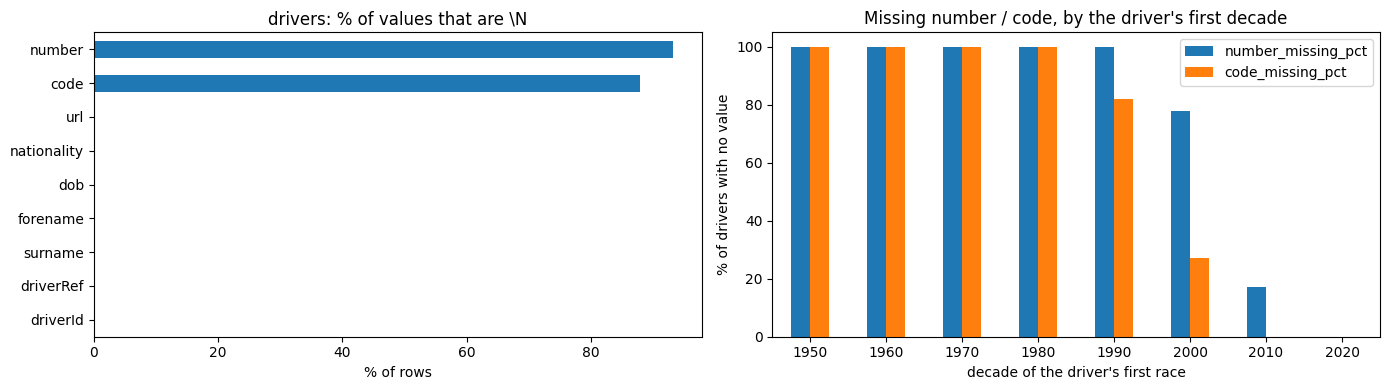

In [6]:
# ==========================================================================================
# A5 · drivers: profile, why number and code are missing, and which columns can identify a driver
# ==========================================================================================

# Why: drivers is joined to results, standings, lap times... so we must know exactly which column
# can safely identify a driver, and why two of its columns (number, code) are mostly empty.
dr = as_num(raw["drivers"])          # exploring copy of drivers (raw stays untouched)

# ---------- 1. Profile card: one row per column ----------
display(profile("drivers"))
print(pk_check("drivers", ["driverId"]))
print(dr.dtypes)                      # note: number is stored as decimals (44.0) only because some values are missing

# ---------- 2. Which column could identify a driver? Test every candidate ----------
# A good identifier has no missing values and never repeats. We test the obvious candidates.
candidates = {"driverId": dr.driverId, "driverRef": dr.driverRef, "url": dr.url,
              "code": dr.code, "number": dr.number, "surname": dr.surname,
              "forename + surname": dr.forename + " " + dr.surname}
id_check = pd.DataFrame({name: {"missing": int(s.isna().sum()),                       # empty cells
                                "repeated values": int(s.dropna().duplicated().sum()),  # values that appear again
                                "usable as identifier": bool(s.isna().sum() == 0 and not s.duplicated().any())}
                         for name, s in candidates.items()}).T
display(id_check)

# ---------- 3. The columns that look like identifiers but are not ----------
shared_codes = dr[dr.code.notna() & dr.code.duplicated(keep=False)].sort_values("code")      # 3-letter code used by 2 drivers
display(shared_codes[["code", "forename", "surname"]])
shared_numbers = dr[dr.number.notna() & dr.number.duplicated(keep=False)].sort_values("number")   # car number used by 2 drivers
print("Car numbers used by more than one driver:", shared_numbers.number.nunique(),
      "numbers, shared by", len(shared_numbers), "drivers")
print("Surnames shared by several drivers:", dr.surname[dr.surname.duplicated()].nunique(),
      "| most common:", dr.surname.value_counts().head(3).to_dict())

# ---------- 4. Small data-quality checks ----------
gaps = sorted(set(range(1, int(dr.driverId.max()) + 1)) - set(dr.driverId))   # driverId values that are skipped
print("driverId runs from", dr.driverId.min(), "to", dr.driverId.max(), "| skipped ids:", gaps)
odd_ref = dr.driverRef[~dr.driverRef.str.match(r"^[a-z0-9_\-]+$")]            # refs are normally lower_case
print("driverRef values with capital letters:", odd_ref.tolist())
print("dob written as YYYY-MM-DD for every driver:", dr.dob.str.match(r"^\d{4}-\d{2}-\d{2}$").all())
print("Names with accented letters:", int(dr.forename.map(lambda s: not s.isascii()).sum() + dr.surname.map(lambda s: not s.isascii()).sum()))

# ---------- 5. WHY are number and code missing? Is it random, or does it depend on the era? ----------
# A driver's first season, taken from the race results
first_year = (results.assign(year=year_of(results), driverId=results.driverId.astype(int))
                     .groupby("driverId").year.min())
dr["debut_year"] = dr.driverId.map(first_year)
dr["debut_decade"] = dr.debut_year // 10 * 10
missing_by_decade = dr.groupby("debut_decade").agg(
    drivers=("driverId", "size"),
    number_missing_pct=("number", lambda s: round(s.isna().mean() * 100)),   # % of these drivers with no car number
    code_missing_pct=("code", lambda s: round(s.isna().mean() * 100)))       # % of these drivers with no 3-letter code
display(missing_by_decade)
modern = dr[dr.debut_year >= 2014]
print("Drivers who debuted from 2014: number present", round(modern.number.notna().mean() * 100), "% | code present",
      round(modern.code.notna().mean() * 100), "%")
print("Drivers who debuted before 2014: with a number:", int(dr[dr.debut_year < 2014].number.notna().sum()),
      "of", int((dr.debut_year < 2014).sum()))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
profile("drivers")["sentinel_%"].sort_values().plot.barh(ax=ax[0], title="drivers: % of values that are \\N")
ax[0].set_xlabel("% of rows")
missing_by_decade[["number_missing_pct", "code_missing_pct"]].plot.bar(
    ax=ax[1], rot=0, title="Missing number / code, by the driver's first decade")
ax[1].set_xlabel("decade of the driver's first race")
ax[1].set_ylabel("% of drivers with no value")
plt.tight_layout()
plt.savefig("figures/A5_drivers_missing.png", dpi=120, bbox_inches="tight")
plt.show()

**A5 result:**
- 861 drivers. **Only two columns have missing values: `number` (93%) and `code` (88%).** Everything else, including `dob` and `nationality`, is complete.
- **The missing values follow the era, not chance.** Every driver who debuted in the 1950s to 1980s has no number and no code; the share falls to 78% (number) and 27% (code) for 2000s debuts, and to **0% for drivers who started from 2014** (permanent car numbers were introduced in 2014; codes became common in the 2000s). So "missing" here means "did not exist yet".
- **Safe identifiers:** `driverId`, `driverRef` and `url` (no missing values, no repeats). Full name also happens to be unique, but names can change spelling, so we do not use it.
- **Not identifiers:** `code` (7 codes are shared by two drivers each, e.g. `VER` is Vergne **and** Verstappen, `MSC` is Michael **and** Mick Schumacher), `number` (11 numbers are reused by 22 drivers) and `surname` (45 surnames are shared, e.g. 5 Taylors).
- Small quirks: `number` is stored as decimals (44.0) only because of the missing values, `driverId` skips 809, three `driverRef` values start with a capital (`Cannoc`, `Changy`, `scott_Brown`), and 61 names have accents (they read correctly).

**Decisions for cleaning:** use `driverId` as the only driver key, never join on `code`, `number` or names; keep `number` and `code` out of the model (they are labels, and their absence only tells the era), or keep them only as text labels in plots; do not fill them in. Date of birth is complete, so age can be computed for every driver (checked in A6).

## A6 · drivers: dates of birth and age at every race

- **What:** convert the `dob` text into real dates (stopping with an error if any cannot be read), look for placeholder-looking dates, join drivers to results and races to compute every driver's age on every race day, check that every age is possible, and see how the age of the grid changed over the decades.
- **Why:** "driver age at the race date" will be a context feature. It is known before the race starts, so it is allowed. But if even one date of birth were wrong, or a placeholder, the feature would quietly mislead the model, so we check before using it.

dob type: datetime64[ns] | earliest: 1896-12-28 | latest: 2005-05-08
Birth decades: {1890: 7, 1900: 40, 1910: 115, 1920: 162, 1930: 140, 1940: 125, 1950: 75, 1960: 72, 1970: 44, 1980: 39, 1990: 35, 2000: 7}
Born on 1 January: 7 (about 2 to 3 would be expected by chance among 861 drivers)
Drivers sharing a birthdate with another driver: 36 in 18 different dates
Age at a race: youngest 17.5 | oldest 58.8
Negative ages: 0 | under 17: 0 | over 55: 4


,surname,year,age
22546,Verstappen,2015,17.5
22558,Verstappen,2015,17.5


,surname,year,age
18522,Chiron,1958,58.8
18912,Chiron,1956,56.8


Drivers with no race at all: 0 | born after their first race: 0
Age at first race: median 28.5 | older than 45: 27 | younger than 18: 1


,median age at first race
debut_decade,
1950,32.8
1960,28.7
1970,28.7
1980,26.6
1990,25.5
2000,24.1
2010,23.0
2020,22.0


Debuts after age 45, by decade of debut: {1950: 24, 1960: 3}
Median driver age per season: 1950 = 39.0 | 1980 = 30.3 | 2024 = 27.9


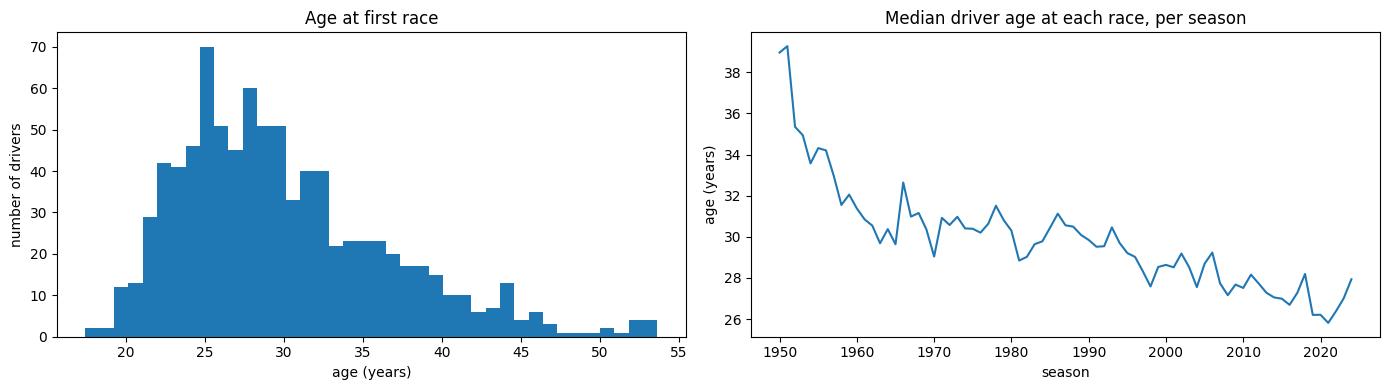

In [7]:
# ==========================================================================================
# A6 · drivers + results + races: dates of birth, and the age of every driver at every race
# ==========================================================================================

# Why: "age at the race date" will be one of our context features, and it is known before the race starts.
# For that, every date of birth must be a real date, and every age must be possible.
dr = as_num(raw["drivers"])           # exploring copy of drivers (raw stays untouched)

# ---------- 1. Turn the text dates into real dates ----------
# errors="raise" makes pandas STOP with an error if even one value cannot be read, so a silent mistake is impossible
dr["dob"] = pd.to_datetime(dr.dob, format="%Y-%m-%d", errors="raise")
print("dob type:", dr.dob.dtype, "| earliest:", dr.dob.min().date(), "| latest:", dr.dob.max().date())
print("Birth decades:", (dr.dob.dt.year // 10 * 10).value_counts().sort_index().to_dict())

# ---------- 2. Does any date look like a placeholder? ----------
# Unknown birthdays are sometimes stored as 1 January. We count them, and drivers sharing the exact same date.
print("Born on 1 January:", int(((dr.dob.dt.month == 1) & (dr.dob.dt.day == 1)).sum()),
      "(about 2 to 3 would be expected by chance among 861 drivers)")
shared = dr[dr.dob.duplicated(keep=False)]
print("Drivers sharing a birthdate with another driver:", len(shared), "in", shared.dob.nunique(), "different dates")

# ---------- 3. Every driver-race pair, with the race date and the driver's date of birth ----------
rr = (results[["raceId", "driverId"]].astype(int)                        # one row per driver per race (from results)
        .merge(races[["raceId", "date", "year"]], on="raceId")            # add the race date
        .merge(dr[["driverId", "surname", "dob"]], on="driverId"))        # add the date of birth
rr["age"] = (rr.date - rr.dob).dt.days / 365.25                          # age in years on the day of the race

# ---------- 4. Are all ages possible? ----------
print("Age at a race: youngest", round(rr.age.min(), 1), "| oldest", round(rr.age.max(), 1))
print("Negative ages:", int((rr.age < 0).sum()), "| under 17:", int((rr.age < 17).sum()), "| over 55:", int((rr.age > 55).sum()))
display(rr.nsmallest(2, "age")[["surname", "year", "age"]].round(1))      # the youngest entries
display(rr.nlargest(2, "age")[["surname", "year", "age"]].round(1))       # the oldest entries
first_race = rr.groupby("driverId").date.min()                            # the date of each driver's first race
dr["debut"] = dr.driverId.map(first_race)
print("Drivers with no race at all:", int(dr.debut.isna().sum()),
      "| born after their first race:", int((dr.dob > dr.debut).sum()))

# ---------- 5. Age at the first race, and how the grid aged over the decades ----------
dr["age_debut"] = (dr.debut - dr.dob).dt.days / 365.25
dr["debut_decade"] = dr.debut.dt.year // 10 * 10
print("Age at first race: median", round(dr.age_debut.median(), 1),
      "| older than 45:", int((dr.age_debut > 45).sum()), "| younger than 18:", int((dr.age_debut < 18).sum()))
display(dr.groupby("debut_decade").age_debut.median().round(1).rename("median age at first race").to_frame())
old = dr[dr.age_debut > 45]
print("Debuts after age 45, by decade of debut:", old.groupby("debut_decade").size().to_dict())
median_age = rr.groupby("year").age.median()                              # median age of all drivers in each season
print("Median driver age per season: 1950 =", round(median_age[1950], 1), "| 1980 =", round(median_age[1980], 1),
      "| 2024 =", round(median_age[2024], 1))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
dr.age_debut.plot.hist(bins=40, ax=ax[0], title="Age at first race")
ax[0].set_xlabel("age (years)")
ax[0].set_ylabel("number of drivers")
median_age.plot(ax=ax[1], title="Median driver age at each race, per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("age (years)")
plt.tight_layout()
plt.savefig("figures/A6_driver_ages.png", dpi=120, bbox_inches="tight")
plt.show()

**A6 result:**
- **All 861 dates of birth are valid dates** (no `\N`, no unreadable text), from 28 December 1896 to 8 May 2005, and none is in the future.
- **Every age is possible.** No driver is born after their first race, no age is negative, none is under 17. The youngest entry is Max Verstappen at **17.5** (2015); the oldest is Louis Chiron at **58.8** (1958); only 4 entries are over 55.
- **No sign of placeholder dates:** 7 drivers were born on 1 January (about 2 to 3 would be expected by chance), and 36 drivers share a birthdate with one other driver (18 dates). That is slightly high but plausible, and the data cannot prove they are placeholders, so we only note it.
- **The grid has become much younger.** The median age at a race fell from **39.0 in 1950 to 30.3 in 1980 and 27.9 in 2024**; the median age at a driver's first race fell from 32.8 (1950s debuts) to 22.0 (2020s). All 27 debuts after age 45 happened in the 1950s (24) and 1960s (3).

**Decisions for cleaning and features:** convert `dob` to a date in the silver table; build `driver_age` as age in years on the race date (it is allowed before the race); expect age to behave differently by era, so remember it in the report's era-sensitivity limitation; do not drop or fix any date of birth.

## A7 · drivers: nationalities, and the first nationality-to-country map (for question 2)

- **What:** list every nationality value, fix inconsistencies on a copy, count drivers and race entries per nationality, and write the **first version of the map from nationality to circuit country**, with three safety checks (a mapped country must exist in `circuits`; a "no circuit" country must not; every nationality must be covered). We then use the map to preview how many home races exist.
- **Why:** question 2 compares podium rates at home and away. A4 showed that circuit countries ("UK") and driver nationalities ("British") are never spelled the same, so without a written map a join would find no home races at all.

Different nationality values: 43
Values with stray spaces: ['Argentinian ']
After trimming and merging 'Argentinian' into 'Argentine': 42


,drivers,race_entries
nationality_clean,,
British,166,4559
Italian,99,3418
French,73,3095
German,50,2430
Brazilian,32,1953
American,158,1315
Finnish,9,1193
Spanish,15,913
Australian,19,893


Nationalities with a single driver: 10


,forename,surname,nationality_clean
339,John,Love,Rhodesian
367,Sam,Tingle,Rhodesian
413,Clive,Puzey,Rhodesian
473,Gary,Hocking,Rhodesian
491,Alfonso,Thiele,American-Italian
573,Alessandro,de Tomaso,Argentine-Italian
709,Ernst,Klodwig,East German
710,Rudolf,Krause,East German
713,Theo,Fitzau,East German


,drivers,race_entries,country,status
nationality_clean,,,,
British,166,4559,UK,mapped
Italian,99,3418,Italy,mapped
French,73,3095,France,mapped
German,50,2430,Germany,mapped
Brazilian,32,1953,Brazil,mapped
American,158,1315,USA,mapped
Finnish,9,1193,Finland,no circuit in that country
Spanish,15,913,Spain,mapped
Australian,19,893,Australia,mapped


Nationalities: 42 | mapped: 25 | no circuit in their country: 13 | mixed or historical: 4
Circuit countries with no driver nationality: 9 of 34 -> ['Azerbaijan', 'Bahrain', 'Korea', 'Morocco', 'Qatar', 'Saudi Arabia', 'Singapore', 'Turkey', 'UAE']
Entries that are a home race: 2523 of 26759 (9.4%) | entries by drivers with a mapped nationality: 24279
Home entries by nationality (top 6): {'American': 525, 'British': 488, 'Italian': 466, 'French': 219, 'German': 208, 'Brazilian': 119}
Nationalities with at least 100 home entries: 6 | at least 30: 13
Indianapolis 500 entries: 405 | of which home entries: 404
Home entries without the Indy 500: 2119 | American home entries: 525 -> 121


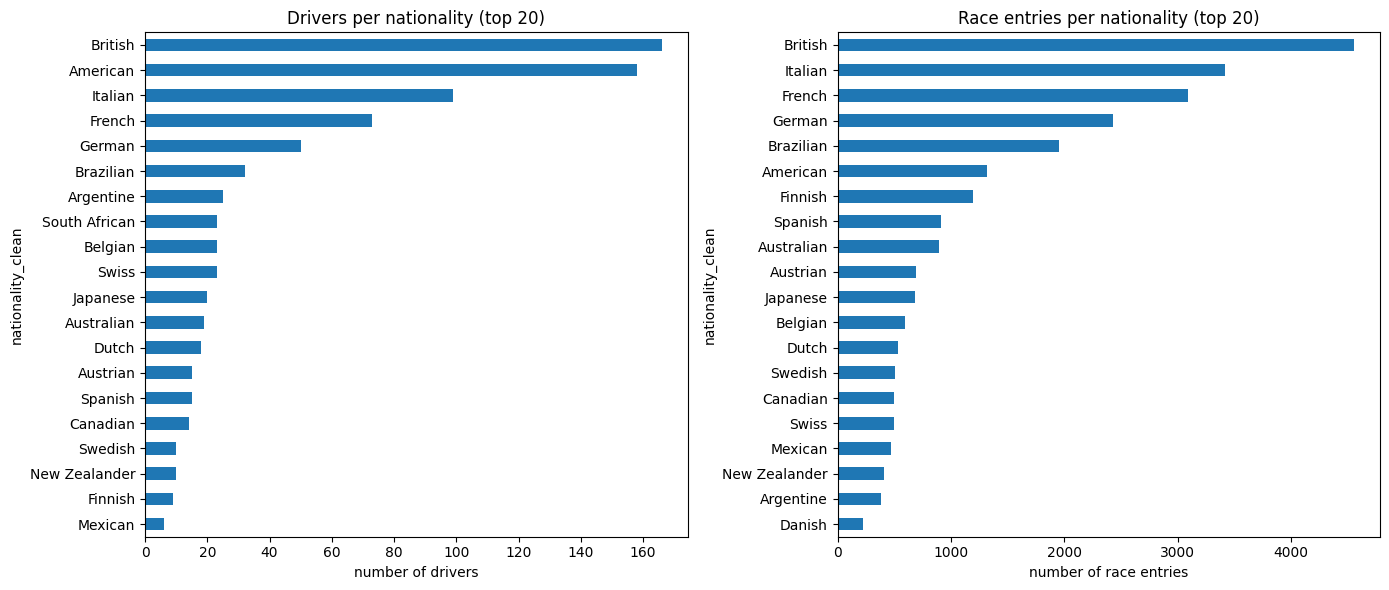

In [8]:
# ==========================================================================================
# A7 · drivers + circuits: driver nationalities, and a first written map to circuit countries (for Q2)
# ==========================================================================================

# Why: question 2 asks whether drivers podium more often at HOME. A4 showed that circuit countries ("UK")
# and driver nationalities ("British") are written differently, so we need a map from one to the other.
# Here we list every nationality, spot inconsistencies, and write the first version of that map.
dr = as_num(raw["drivers"])           # exploring copy of drivers (raw stays untouched)
ci = as_num(raw["circuits"])          # exploring copy of circuits

# ---------- 1. Every nationality value, and the inconsistencies ----------
print("Different nationality values:", dr.nationality.nunique())
print("Values with stray spaces:", list(dr.nationality[dr.nationality != dr.nationality.str.strip()].unique()))
# Fix on a COPY: remove stray spaces, and merge "Argentinian" into "Argentine" (the same nationality, written two ways)
dr["nationality_clean"] = dr.nationality.str.strip().replace({"Argentinian": "Argentine"})
print("After trimming and merging 'Argentinian' into 'Argentine':", dr.nationality_clean.nunique())

# ---------- 2. How many drivers, and how many race entries, does each nationality have? ----------
entries = (results[["raceId", "driverId"]].astype(int)                        # one row per driver per race
           .merge(dr[["driverId", "nationality_clean"]], on="driverId"))      # add the driver's nationality
per_nat = pd.DataFrame({"drivers": dr.nationality_clean.value_counts(),                # number of different drivers
                        "race_entries": entries.nationality_clean.value_counts()       # number of race starts and entries
                        }).fillna(0).astype(int).sort_values("race_entries", ascending=False)
display(per_nat.head(10))
print("Nationalities with a single driver:", int((per_nat.drivers == 1).sum()))

# ---------- 3. Mixed and historical nationalities ----------
MIXED = ["American-Italian", "Argentine-Italian", "East German", "Rhodesian"]    # two countries, or a country that no longer exists
display(dr[dr.nationality_clean.isin(MIXED)][["forename", "surname", "nationality_clean"]])

# ---------- 4. The first version of the nationality -> country map ----------
# Circuit countries as written in circuits (with the two USA spellings merged, as decided in A4)
circuit_countries = set(ci.country.replace({"United States": "USA"}))
NAT_TO_COUNTRY = {                       # nationality -> the way the SAME country is written in circuits
    "American": "USA", "Argentine": "Argentina", "Australian": "Australia", "Austrian": "Austria",
    "Belgian": "Belgium", "Brazilian": "Brazil", "British": "UK", "Canadian": "Canada", "Chinese": "China",
    "Dutch": "Netherlands", "French": "France", "German": "Germany", "Hungarian": "Hungary", "Indian": "India",
    "Italian": "Italy", "Japanese": "Japan", "Malaysian": "Malaysia", "Mexican": "Mexico", "Monegasque": "Monaco",
    "Portuguese": "Portugal", "Russian": "Russia", "South African": "South Africa", "Spanish": "Spain",
    "Swedish": "Sweden", "Swiss": "Switzerland"}
NO_CIRCUIT = {                           # nationalities whose country has no F1 circuit in the data: a home race is impossible
    "Chilean": "Chile", "Colombian": "Colombia", "Czech": "Czech Republic", "Danish": "Denmark", "Finnish": "Finland",
    "Indonesian": "Indonesia", "Irish": "Ireland", "Liechtensteiner": "Liechtenstein", "New Zealander": "New Zealand",
    "Polish": "Poland", "Thai": "Thailand", "Uruguayan": "Uruguay", "Venezuelan": "Venezuela"}
# Three safety checks, so the map cannot silently be wrong:
assert set(NAT_TO_COUNTRY.values()) <= circuit_countries, "a mapped country is not spelled like a circuit country"
assert not (set(NO_CIRCUIT.values()) & circuit_countries), "a 'no circuit' country does have a circuit"
assert set(NAT_TO_COUNTRY) | set(NO_CIRCUIT) | set(MIXED) == set(dr.nationality_clean), "some nationality is not covered"

def map_status(nat):
    if nat in NAT_TO_COUNTRY: return "mapped"
    if nat in NO_CIRCUIT: return "no circuit in that country"
    return "mixed or historical: decide in Q2"
map_table = per_nat.copy()
map_table["country"] = map_table.index.map(lambda n: NAT_TO_COUNTRY.get(n, NO_CIRCUIT.get(n, "")))
map_table["status"] = map_table.index.map(map_status)
display(map_table)
print("Nationalities:", len(map_table), "| mapped:", int((map_table.status == "mapped").sum()),
      "| no circuit in their country:", int((map_table.status == "no circuit in that country").sum()),
      "| mixed or historical:", int((map_table.status == "mixed or historical: decide in Q2").sum()))
no_driver = sorted(circuit_countries - set(NAT_TO_COUNTRY.values()))        # circuit countries with no driver nationality
print("Circuit countries with no driver nationality:", len(no_driver), "of", len(circuit_countries), "->", no_driver)

# ---------- 5. A first look at how many home races exist (before any cleaning) ----------
entries["driver_country"] = entries.nationality_clean.map(NAT_TO_COUNTRY)                # the driver's country (NaN if unmapped)
race_country = (races[["raceId", "circuitId"]].merge(ci[["circuitId", "country"]], on="circuitId")
                .assign(circuit_country=lambda d: d.country.replace({"United States": "USA"}))[["raceId", "circuit_country"]])
entries = entries.merge(race_country, on="raceId")                                       # add the circuit's country
entries["is_home"] = entries.driver_country == entries.circuit_country                   # True for a home race
print("Entries that are a home race:", int(entries.is_home.sum()), "of", len(entries),
      f"({entries.is_home.mean() * 100:.1f}%) | entries by drivers with a mapped nationality:", int(entries.driver_country.notna().sum()))
home_by_nat = entries[entries.is_home].groupby("nationality_clean").size().sort_values(ascending=False)
print("Home entries by nationality (top 6):", home_by_nat.head(6).to_dict())
print("Nationalities with at least 100 home entries:", int((home_by_nat >= 100).sum()), "| at least 30:", int((home_by_nat >= 30).sum()))

# The Indianapolis 500 (1950-1960) counted as a championship race, but almost only Americans entered it. Does it inflate the US numbers?
indy_races = set(races.loc[races.name.str.contains("Indianapolis 500"), "raceId"])       # the 11 Indy 500 races
entries["is_indy500"] = entries.raceId.isin(indy_races)
print("Indianapolis 500 entries:", int(entries.is_indy500.sum()), "| of which home entries:", int((entries.is_indy500 & entries.is_home).sum()))
home_no_indy = entries[entries.is_home & ~entries.is_indy500].groupby("nationality_clean").size().sort_values(ascending=False)
print("Home entries without the Indy 500:", int(home_no_indy.sum()),
      "| American home entries:", int(home_by_nat["American"]), "->", int(home_no_indy.get("American", 0)))

# ---------- 6. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
per_nat.drivers.sort_values(ascending=False).head(20).sort_values().plot.barh(ax=ax[0], title="Drivers per nationality (top 20)")
ax[0].set_xlabel("number of drivers")
per_nat.race_entries.head(20).sort_values().plot.barh(ax=ax[1], title="Race entries per nationality (top 20)")
ax[1].set_xlabel("number of race entries")
plt.tight_layout()
plt.savefig("figures/A7_nationalities.png", dpi=120, bbox_inches="tight")
plt.show()

**A7 result:**
- **43 nationality values, 42 real nationalities.** `Argentinian ` (with a trailing space) is the same nationality as `Argentine`, so we trim and merge it.
- **The map covers all 42:** **25 nationalities map to a circuit country** (British to UK, Monegasque to Monaco, American to USA, ...), **13 have no circuit in their country** (for example Finnish, Danish, New Zealander, Polish, Thai), so those drivers can never have a home race, and **4 are mixed or historical** (American-Italian, Argentine-Italian, East German, Rhodesian: 9 drivers in total) and need a decision in Q2.
- **The other direction too:** **9 of the 34 circuit countries have no driver nationality at all** (Azerbaijan, Bahrain, Korea, Morocco, Qatar, Saudi Arabia, Singapore, Turkey, UAE), so races there are never home races.
- **Drivers and entries rank differently.** Americans are the second largest group by drivers (158) but only sixth by race entries (1,315), while Finns are only 9 drivers with 1,193 entries, but no Finnish circuit.
- **A preview of Q2's sample:** 2,523 of the 26,759 entries (9.4%) are home races, mostly British, Italian, French, German and American drivers. **But 404 of the 405 Indianapolis 500 entries are Americans at home.** Without that race, American home entries fall from **525 to 121** and the total from 2,523 to **2,119**. Only 6 nationalities have 100 or more home entries.

**Decisions for cleaning and Q2:** trim spaces and merge `Argentinian` into `Argentine`; keep the written map as a table in the notebook; decide the four mixed or historical nationalities in the Q2 task; **exclude the Indianapolis 500 from Q2** (or report with and without it), because it makes American home advantage look much bigger than it is; remember that these counts still include non-starters, which T6 will remove.

## A8 · constructors: profile, activity, and whether "a constructor" is one continuous team

- **What:** profile the `constructors` table and its keys, count how many races each constructor entered (using `results`), and test two things we have been assuming: that one team is **one** constructor, and that a constructor is **one continuous** team. We also look at who was active in the modern era, how many cars a team entered, and the Indianapolis 500.
- **Why:** question 3 compares constructors, and "team form" (how well a team did in earlier races) will be a feature. If one team hides under several IDs, or one ID covers teams that raced decades apart, a team's "form" would be computed from the wrong history.

,sentinel_N,sentinel_%,empty_str,unique,numeric_%,example
constructorId,0,0.0,0,212,100.0,1
constructorRef,0,0.0,0,212,0.0,mclaren
name,0,0.0,0,212,0.0,McLaren
nationality,0,0.0,0,24,0.0,British
url,0,0.0,0,175,0.0,http://en.wikipedia.org/wiki/McLaren


{'table': 'constructors', 'key': 'constructorId', 'rows': 212, 'duplicates': 0, 'null_or_sentinel': 0}
constructorRef unique: True | name unique: True | url unique: False
constructorId runs from 1 to 215 | skipped ids: [43, 165, 212]
Constructor nationalities not used by any driver: ['Hong Kong'] | different nationalities: 24
Constructors with no result rows: [['eagle', 'Eagle']]
With 5 or fewer entries: 70 | racing in a single season only: 70 | with 100 or more entries: 56 | with 1,000 or more: 3


,name,entries,first,last
5,Ferrari,2439.0,1950.0,2024.0
0,McLaren,1923.0,1968.0,2024.0
2,Williams,1676.0,1975.0,2024.0
24,Tyrrell,881.0,1970.0,1998.0
31,Team Lotus,871.0,1958.0,1994.0


Constructors that share a Wikipedia page with another constructor: 50 in 13 groups


,constructorIds,names
url,,
http://en.wikipedia.org/wiki/Cooper_Car_Company,11,"Cooper, Cooper-ATS, Cooper-Alfa Romeo, Cooper-..."
http://en.wikipedia.org/wiki/Team_Lotus,7,"Lotus-BRM, Lotus-Borgward, Lotus-Climax, Lotus..."
http://en.wikipedia.org/wiki/Brabham,6,"Brabham, Brabham-Alfa Romeo, Brabham-BRM, Brab..."
http://en.wikipedia.org/wiki/De_Tomaso,4,"De Tomaso, De Tomaso-Alfa Romeo, De Tomaso-Fer..."
http://en.wikipedia.org/wiki/Anglo_American_Racers,3,"Eagle, Eagle-Climax, Eagle-Weslake"
http://en.wikipedia.org/wiki/Shadow_Racing_Cars,3,"Shadow, Shadow-Ford, Shadow-Matra"


,name,first,last,entries,longest_break_seasons
31,Team Lotus,1958.0,1994.0,871.0,6
14,Sauber,1993.0,2024.0,837.0,5
3,Renault,1977.0,2020.0,787.0,16
33,Brabham,1962.0,1992.0,662.0,6
129,Mercedes,1954.0,2024.0,652.0,54
20,Arrows,1978.0,2002.0,590.0,6
49,Alfa Romeo,1950.0,2023.0,451.0,33
115,Aston Martin,1959.0,2024.0,191.0,60
25,Lola,1962.0,1997.0,165.0,9
52,ATS,1963.0,1984.0,162.0,14


,name,nationality,first,last,entries
5,Ferrari,Italian,1950.0,2024.0,2439.0
49,Alfa Romeo,Swiss,1950.0,2023.0,451.0
129,Mercedes,German,1954.0,2024.0,652.0
115,Aston Martin,British,1959.0,2024.0,191.0
0,McLaren,British,1968.0,2024.0,1923.0
2,Williams,British,1975.0,2024.0,1676.0
3,Renault,French,1977.0,2020.0,787.0
14,Sauber,Swiss,1993.0,2024.0,837.0
8,Red Bull,Austrian,2005.0,2024.0,788.0
4,Toro Rosso,Italian,2006.0,2019.0,536.0


Different constructors in 2014-2021: 19
Different constructors in 2022-2024: 12
Constructors that only ever raced the Indianapolis 500: 31 | their entries: 176
Most cars one constructor entered in a single race: at the Indy 500 = 35 | at all other races = 15


,median,max
decade,,
1950,3.0,15
1960,2.0,11
1970,2.0,7
1980,2.0,4
1990,2.0,2
2000,2.0,2
2010,2.0,2
2020,2.0,2


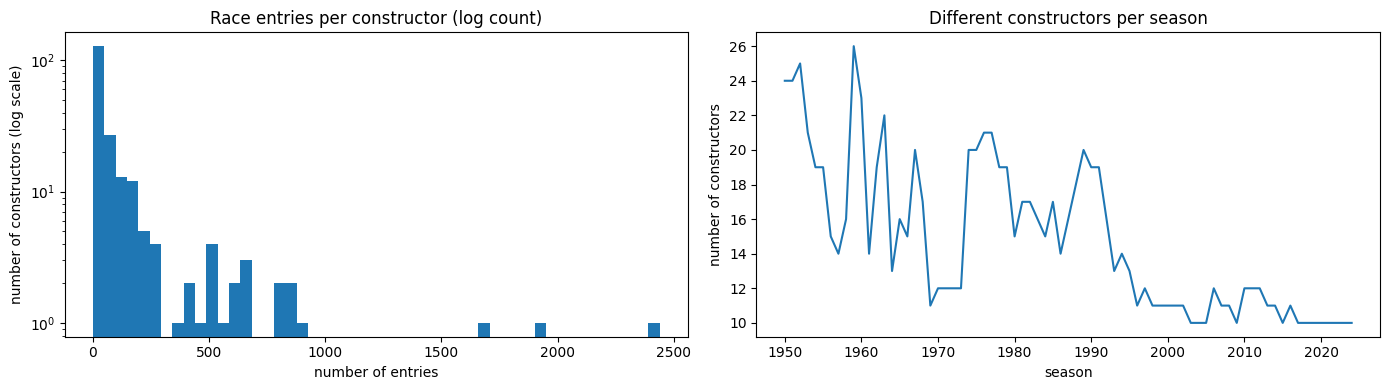

In [9]:
# ==========================================================================================
# A8 · constructors + results: profile, how active each team was, and how team identity behaves over time
# ==========================================================================================

# Why: question 3 compares constructors, and "team form" will be a feature. Both assume that a constructor is ONE
# continuous team. We check whether that is true, and how many constructors are too small to rank.
co = as_num(raw["constructors"])      # exploring copy of constructors (raw stays untouched)

# ---------- 1. Profile card, keys and types ----------
display(profile("constructors"))
print(pk_check("constructors", ["constructorId"]))
print("constructorRef unique:", co.constructorRef.is_unique, "| name unique:", co.name.is_unique, "| url unique:", co.url.is_unique)
gaps = sorted(set(range(1, int(co.constructorId.max()) + 1)) - set(co.constructorId))     # constructorId values that are skipped
print("constructorId runs from", co.constructorId.min(), "to", co.constructorId.max(), "| skipped ids:", gaps)
driver_nationalities = set(raw["drivers"]["nationality"].str.strip())                      # the vocabulary used for drivers (A7)
print("Constructor nationalities not used by any driver:", sorted(set(co.nationality) - driver_nationalities),
      "| different nationalities:", co.nationality.nunique())

# ---------- 2. How active was each constructor? ----------
entries = results[["raceId", "constructorId"]].astype(int)                                  # one row per car per race (ids as numbers)
entries["year"] = entries.raceId.map(YEAR)                                                  # the season of each race
entries = entries.merge(races[["raceId", "name"]].rename(columns={"name": "race_name"}), on="raceId")   # add the race name
act = entries.groupby("constructorId").agg(entries=("raceId", "size"),        # number of cars entered
                                           races=("raceId", "nunique"),       # number of different races
                                           first=("year", "min"), last=("year", "max"))
co2 = co.merge(act, left_on="constructorId", right_index=True, how="left")    # attach to the constructors table (a copy)
print("Constructors with no result rows:", co2[co2.entries.isna()][["constructorRef", "name"]].values.tolist())
print("With 5 or fewer entries:", int((co2.entries <= 5).sum()), "| racing in a single season only:", int((co2["first"] == co2["last"]).sum()),
      "| with 100 or more entries:", int((co2.entries >= 100).sum()), "| with 1,000 or more:", int((co2.entries >= 1000).sum()))
display(co2.nlargest(5, "entries")[["name", "entries", "first", "last"]])

# ---------- 3. Is one constructor always one continuous team? Test 1: one team split over several constructorIds ----------
# Constructors that point to the SAME Wikipedia page are usually one chassis builder paired with different engines
same_page = co[co.url.duplicated(keep=False)].groupby("url").agg(constructorIds=("constructorId", "size"),
                                                                 names=("name", lambda s: ", ".join(sorted(s)[:4]) + (" ..." if len(s) > 4 else "")))
print("Constructors that share a Wikipedia page with another constructor:", int(co.url.duplicated(keep=False).sum()), "in", len(same_page), "groups")
display(same_page.sort_values("constructorIds", ascending=False).head(6))

# ---------- 4. Test 2: one constructorId covering separate periods, years apart ----------
seasons = entries.groupby("constructorId").year.apply(lambda s: sorted(s.unique()))      # the seasons each constructor raced
def longest_break(ys):                                                                    # most consecutive seasons missed in a row
    return max([b - a - 1 for a, b in zip(ys, ys[1:])], default=0)
co2["longest_break_seasons"] = co2.constructorId.map(lambda c: longest_break(seasons.get(c, [])))
display(co2[(co2.longest_break_seasons >= 5) & (co2.entries >= 50)].sort_values("entries", ascending=False)
        [["name", "first", "last", "entries", "longest_break_seasons"]])

# ---------- 5. Who was active in the modern era? (renamed teams are separate constructors) ----------
display(co2[co2["last"] >= 2014].sort_values("first")[["name", "nationality", "first", "last", "entries"]])
for a, b in [(2014, 2021), (2022, 2024)]:                                                 # the two periods of question 3
    print(f"Different constructors in {a}-{b}:", entries[(entries.year >= a) & (entries.year <= b)].constructorId.nunique())

# ---------- 6. Cars per team per race, and the Indianapolis 500 ----------
indy = entries.race_name.str.contains("Indianapolis 500")                                 # the 11 Indy 500 races (1950-1960)
only_indy = set(entries[indy].constructorId) - set(entries[~indy].constructorId)          # constructors that raced nowhere else
print("Constructors that only ever raced the Indianapolis 500:", len(only_indy), "| their entries:",
      int(entries.constructorId.isin(only_indy).sum()))
cars = entries.groupby(["year", "constructorId", "raceId"]).size().reset_index(name="cars")   # cars one team entered in one race
cars["indy"] = cars.raceId.isin(entries[indy].raceId)
print("Most cars one constructor entered in a single race: at the Indy 500 =", int(cars[cars.indy].cars.max()),
      "| at all other races =", int(cars[~cars.indy].cars.max()))
display(cars[~cars.indy].groupby(cars.year // 10 * 10).cars.agg(["median", "max"]).rename_axis("decade"))

# ---------- 7. Plots (saved for the report) ----------
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
co2.entries.plot.hist(bins=50, logy=True, ax=ax[0], title="Race entries per constructor (log count)")
ax[0].set_xlabel("number of entries")
ax[0].set_ylabel("number of constructors (log scale)")
entries.groupby("year").constructorId.nunique().plot(ax=ax[1], title="Different constructors per season")
ax[1].set_xlabel("season")
ax[1].set_ylabel("number of constructors")
plt.tight_layout()
plt.savefig("figures/A8_constructors.png", dpi=120, bbox_inches="tight")
plt.show()

**A8 result:**
- **The table is clean:** 212 constructors, no `\N`, and `constructorId`, `constructorRef` and `name` are all unique. Only `constructorId` skips three numbers (43, 165, 212), and the one nationality that no driver has is `Hong Kong`.
- **Most constructors are tiny:** **70** raced 5 or fewer times, all in a single season; only **56** have 100 or more entries and only 3 have 1,000 or more (Ferrari 2,439, McLaren 1,923, Williams 1,676). **Eagle** never appears in `results`.
- **One team is often split over several IDs.** 50 constructors share a Wikipedia page with another one (13 groups): the same chassis builder paired with different engines, such as **Cooper (11 IDs), Team Lotus (7), Brabham (6)**. So a team's history is scattered over several `constructorId`s in the 1950s to 1970s.
- **One ID can cover separate periods.** Aston Martin raced 1959–60 and again from 2021 (a 60-season break); Alfa Romeo 1950–85 and 2019–23; Renault 1977–85, 2002–11 and 2016–20; Mercedes 1954–55 and from 2010. A "last 5 races" window on such an ID would reach back decades.
- **Renamed modern teams are separate constructors:** Force India, Racing Point and Aston Martin; Toro Rosso, AlphaTauri and RB; Lotus F1 and Alpine. There are 20 constructors active from 2014, **19 in 2014–2021 and 12 in 2022–2024** (the numbers question 3 will use).
- **Cars per team:** from the 1990s every team enters exactly 2 cars; the 1950s had up to 15 per team. The Indianapolis 500 is odd: **31 constructors raced nowhere else** (176 entries) and one chassis builder had **35 cars** in a single race.
- **The field shrank from 24–26 teams in the 1950s to a steady 10 since 2003.**

**Decisions for cleaning and features:** use `constructorId` as the team key but **do not trust it as one continuous team**: compute team form only from a recent time window (for example the previous 1 or 2 seasons) so a long gap resets it, and add a "prior entries" count; state in the report that renamed teams reset history; for Q3 set a minimum number of starts and mention the renames; **exclude the Indianapolis 500** (its constructors are chassis builders, not teams); keep Eagle, it is harmless.